# Graph Transformer Policy — Multi-N Training
### attention = graph message passing · C3 (triangle-free) · generalise to unseen N

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import Adam

from transformer_policy import GraphTransformerPolicy
from turan_env_c import CEnv, CHECKER_C3
from ppo3 import train_multi_n, save_checkpoint

print(f"torch {torch.__version__}  cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  {torch.cuda.get_device_name(0)}")

# quick sanity: _infer_n round-trips for all sizes we'll use
for n in [10, 12, 15, 18, 20, 25]:
    na = n * (n-1) // 2
    assert GraphTransformerPolicy._infer_n(na) == n, f"_infer_n failed for n={n}"
print("_infer_n OK for n in [10,12,15,18,20,25]")

/root/backtoRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


torch 2.10.0+cu130  cuda=True
  NVIDIA GeForce RTX 5090
_infer_n OK for n in [10,12,15,18,20,25]


## Checkpoint helper

In [ ]:
def load_transformer_checkpoint(path, device='cuda'):
    """Load a GraphTransformerPolicy checkpoint saved by save_checkpoint."""
    ckpt      = torch.load(path, map_location='cpu')
    cfg       = ckpt['cfg']
    policy    = GraphTransformerPolicy(
        d_model  = cfg['d_model'],
        n_heads  = cfg['n_heads'],
        n_layers = cfg['n_layers'],
    ).to(device)
    optimizer = Adam(policy.parameters(), lr=cfg['lr'])
    policy.load_state_dict(ckpt['policy'])
    optimizer.load_state_dict(ckpt['optimizer'])
    policy = torch.compile(policy, dynamic=True)
    print(f"loaded {path}")
    print(f"  iter={ckpt['iteration']}  steps={ckpt['global_step']:,}  best={ckpt['best_mean_ret']:.2f}")
    return policy, optimizer, cfg, ckpt['iteration'], ckpt['global_step'], ckpt['best_mean_ret']


## Config

In [7]:
N_TRAIN  = [10, 12, 15, 18, 20]  # curriculum order — also the cycle order
N_TEST   = 25                     # generalisation eval, never seen during training
N_CYCLES = 3                      # how many times to lap through N_TRAIN
                                  # each full lap: 10→12→15→18→20, shared weights throughout

# To resume from a checkpoint and keep cycling:
RESUME   = None   # e.g. './checkpoints_transformer/best_n20.pt'

# Turán / Mantel bound for triangle-free graphs: ex(n, C3) = floor(n²/4)
TURAN_BOUND = {n: n**2 // 4 for n in N_TRAIN + [N_TEST]}
print("Turán bounds (triangle-free):", TURAN_BOUND)

CFG = dict(
    # transformer architecture
    d_model        = 128,
    n_heads        = 4,
    n_layers       = 3,
    # env
    num_envs       = 512,
    checker_id     = CHECKER_C3,
    # PPO
    n_steps        = 64,
    n_epochs       = 10,
    batch_size     = 2048,
    lr             = 1e-4,
    gamma          = 0.99,
    gae_lambda     = 0.95,
    clip_eps       = 0.2,
    vf_coef        = 0.5,
    ent_coef       = 0.05,
    max_grad_norm  = 0.5,
    # steps spent on each n per cycle
    total_steps_per_n = 4_000_000,
    log_interval   = 50,
    device         = 'cuda',
    checkpoint_dir = './checkpoints_transformer',
)

for k, v in CFG.items():
    print(f"  {k:22s} = {v}")


Turán bounds (triangle-free): {10: 25, 12: 36, 15: 56, 18: 81, 20: 100, 25: 156}
  d_model                = 128
  n_heads                = 4
  n_layers               = 3
  num_envs               = 512
  checker_id             = 0
  n_steps                = 64
  n_epochs               = 10
  batch_size             = 2048
  lr                     = 1e-05
  gamma                  = 0.99
  gae_lambda             = 0.95
  clip_eps               = 0.2
  vf_coef                = 0.5
  ent_coef               = 0.07
  max_grad_norm          = 0.5
  total_steps_per_n      = 4000000
  log_interval           = 50
  device                 = cuda
  checkpoint_dir         = ./checkpoints_transformer


## Build policy and envs

In [8]:
device = torch.device(CFG['device'])
os.makedirs(CFG['checkpoint_dir'], exist_ok=True)

if RESUME:
    policy, optimizer, _, _, gs, _ = load_transformer_checkpoint(RESUME, device=CFG['device'])
    # override lr from current CFG (useful when resuming with a different lr)
    for g in optimizer.param_groups:
        g['lr'] = CFG['lr']
    print(f"Resuming from step {gs:,} — will run {N_CYCLES} more cycle(s)")
else:
    # fresh policy — compiled with dynamic=True so one graph handles all n
    policy = GraphTransformerPolicy(
        d_model  = CFG['d_model'],
        n_heads  = CFG['n_heads'],
        n_layers = CFG['n_layers'],
    ).to(device)
    policy    = torch.compile(policy, dynamic=True)
    optimizer = Adam(policy.parameters(), lr=CFG['lr'])
    gs        = 0

print(f"GraphTransformerPolicy  params: {sum(p.numel() for p in policy.parameters()):,}")


GraphTransformerPolicy  params: 626,562


## Multi-N training loop
Curriculum: train on each n in order from smallest to largest.  
All iterations share the same policy + optimizer, so gradients from every n shape the same weights.

In [9]:
policy, history = train_multi_n(N_TRAIN, policy, optimizer, CFG,
                                n_cycles=N_CYCLES, global_step=gs)


## Training curves (colour-coded per n)

In [10]:
import matplotlib.cm as cm

colors = {n: cm.viridis(i / max(len(N_TRAIN) - 1, 1)) for i, n in enumerate(N_TRAIN)}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for n in N_TRAIN:
    h_n   = [h for h in history if h['n'] == n]
    steps = [h['global_step'] / 1e6 for h in h_n]
    rets  = [h['mean_ret']           for h in h_n]
    pg    = [h['pg']                 for h in h_n]
    vf    = [h['vf']                 for h in h_n]
    ent   = [h['ent']                for h in h_n]
    fps_h = [h['fps']                for h in h_n]
    bound = TURAN_BOUND[n]
    c     = colors[n]
    label = f'n={n} (bound={bound})'

    axes[0,0].plot(steps, rets,  color=c, label=label)
    axes[0,1].plot(steps, pg,    color=c)
    axes[0,2].plot(steps, vf,    color=c)
    axes[1,0].plot(steps, ent,   color=c)
    axes[1,1].plot(steps, fps_h, color=c)
    axes[1,2].plot(steps, [r / bound for r in rets], color=c, label=label)

# vertical dashed lines at cycle boundaries
steps_per_cycle = CFG['total_steps_per_n'] * len(N_TRAIN) / 1e6
for ax in axes.flat:
    for c_idx in range(1, N_CYCLES):
        ax.axvline(gs / 1e6 + c_idx * steps_per_cycle,
                   color='gray', linestyle=':', linewidth=0.8)

axes[0,0].set_title('Mean Return');           axes[0,0].set_xlabel('steps (M)'); axes[0,0].legend(fontsize=7)
axes[0,1].set_title('Policy Loss');           axes[0,1].set_xlabel('steps (M)')
axes[0,2].set_title('Value Loss');            axes[0,2].set_xlabel('steps (M)')
axes[1,0].set_title('Entropy');               axes[1,0].set_xlabel('steps (M)')
axes[1,1].set_title('FPS');                   axes[1,1].set_xlabel('steps (M)')
axes[1,2].set_title('Return / Turán bound');  axes[1,2].set_xlabel('steps (M)'); axes[1,2].legend(fontsize=7)

plt.suptitle(f'Graph Transformer — {N_CYCLES} cycle(s) over {N_TRAIN}  (C3 / triangle-free)', fontsize=12)
plt.tight_layout()
plt.show()


## Generalisation eval — rollout on N_TEST=25 (never seen during training)

N_TEST=25  Turán bound=156
Edge counts: [67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67]
Best found : 67  (42.9% of bound)


/tmp/ipykernel_22074/2091240816.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


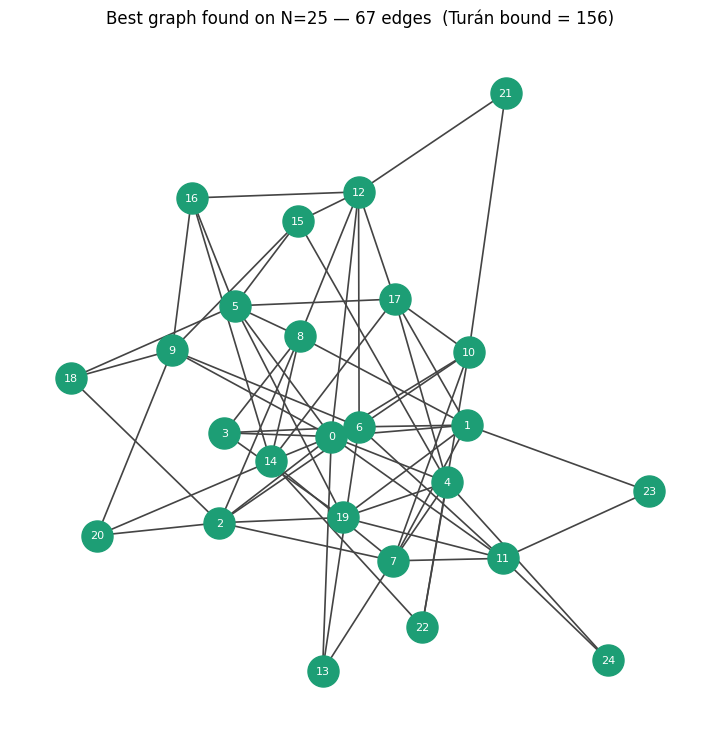

In [11]:
import networkx as nx

def run_episodes_transformer(policy, n, num_episodes, checker_id, device, deterministic=True):
    """Deterministic/stochastic rollouts on a fresh CEnv of size n."""
    env      = CEnv(n=n, num_envs=num_episodes, checker_id=checker_id)
    obs      = env.reset()
    done_all = np.zeros(num_episodes, dtype=bool)
    last_obs = np.zeros((num_episodes, env.num_actions), dtype=np.float32)
    max_steps = env.num_actions + 10

    policy.eval()
    for _ in range(max_steps):
        if done_all.all():
            break
        obs_t = torch.from_numpy(obs).to(device)
        with torch.no_grad(), torch.autocast('cuda', dtype=torch.bfloat16):
            logits, _ = policy(obs_t.bfloat16())
        logits = logits.float()
        logits[obs_t] = -1e9   # mask already-added edges

        action = logits.argmax(dim=-1) if deterministic else \
                 torch.distributions.Categorical(logits=logits).sample()

        obs, _, done_arr = env.step(action.cpu().numpy().astype(np.int32))
        newly_done = done_arr & ~done_all
        for e in np.where(newly_done)[0]:
            last_obs[e] = obs_t[e].cpu().numpy().astype(np.float32)
        done_all |= done_arr

    # fill any episodes that hit max_steps without terminating
    for e in np.where(~done_all)[0]:
        last_obs[e] = obs_t[e].cpu().numpy().astype(np.float32)

    env.close()

    # reconstruct symmetric n×n adjacency matrices
    us, vs = np.triu_indices(n, k=1)
    adjs = []
    for e in range(num_episodes):
        adj = np.zeros((n, n), dtype=np.float32)
        adj[us, vs] = last_obs[e]
        adj[vs, us] = last_obs[e]
        adjs.append(adj)
    return adjs


# ── run on N_TEST ──
N_EPISODES = 32
adjs        = run_episodes_transformer(policy, N_TEST, N_EPISODES,
                                       CHECKER_C3, device, deterministic=True)

edge_counts = [int(adj.sum()) // 2 for adj in adjs]
bound       = TURAN_BOUND[N_TEST]
print(f"N_TEST={N_TEST}  Turán bound={bound}")
print(f"Edge counts: {sorted(edge_counts, reverse=True)}")
print(f"Best found : {max(edge_counts)}  ({max(edge_counts)/bound*100:.1f}% of bound)")

# ── draw the densest graph found ──
best_adj = adjs[np.argmax(edge_counts)]
G   = nx.from_numpy_array(best_adj)
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(7, 7))
nx.draw(G, pos, with_labels=True,
        node_color='#1D9E75', node_size=500,
        font_color='white', font_size=8,
        edge_color='#444', width=1.2)
plt.title(f"Best graph found on N={N_TEST} — {max(edge_counts)} edges  "
          f"(Turán bound = {bound})")
plt.tight_layout()
plt.show()